# How many fatal crashes occur near Philadelphia schools?

![](images/school_district.jpg){width=800}

Traffic safety in cities is among the most critcal concerns for police and public safety personnel. Especially within Philadelphia, students walk, bike, scooter, or are dropped off during busy traffic hours. Philadelphia has strategically increased the implementation of programs to reduce traffic injuries near school areas. Even with these safety measures, I wanted to observe how many fatal collisions occur around Philadelphia schools and what schools need more safety measures in place. 

In [1]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt

In [2]:
crash_data = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

In [8]:
crashes = pd.read_csv('data/fatal_crashes.csv')
schools = pd.read_csv('data/Schools.csv')

In [30]:
outside_bounds = crashes['lng'] < -76
crashes = crashes[~outside_bounds]

# Analyzing the fatal crashes that occured in the most recent recorded year: 2025

In [26]:
c2025 = crashes[crashes['year'] == 2025]

In [103]:
c2025 = crashes[crashes['year'] == 2025]

c2025_gpd = gpd.GeoDataFrame(c2025,geometry=gpd.points_from_xy(c2025['lng'], c2025['lat']))

c2025_gpd.crs = 'epsg:4326'

#### Plotting random sample of 99 incidents in Philadelphia to see distribution: 

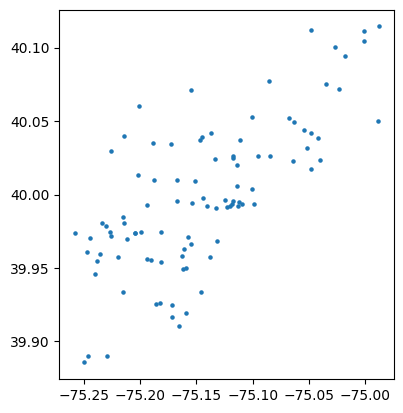

In [182]:
c2025_gpd.sample(99).plot(markersize=5,
       categorical=True, legend=True)
plt.show()

#### This a spatial distribution of all the fatal incidents reported in 2025 in the city of Philadelphia. 
- x-axis = longitude
- y-axis = latitude 

Based on the graph, it seems that a lot of the fatal accidents were spread across the city of Philadelphia. There seems to be more points clustering around the middle of the city roughly -75.10 and 40.00, which encompasses sort of West Philadelphia into Center City and North Philadelphia. Most of the fatal accidents occupy in the city areas, with far regions much more isolated. This makes sense because cities are much more densely populated with ongoing traffic. 

# Locating the schools in Philadelphia 

In [104]:
schools_gpd = gpd.GeoDataFrame(schools, geometry=gpd.points_from_xy(schools['X'], schools['Y']))
schools_gpd.crs = "EPSG:3857"
schools_gpd = schools_gpd.to_crs(crs=4326)
schools_gpd.shape

(490, 17)

![](images/logo.jpg){width=500}

#### There are 490 schools in the city of Philadelphia

In [42]:
zip_gpd=gpd.read_file('data/Zipcodes_Poly.geojson').to_crs(crs=4326)

# The schools location on a map: 

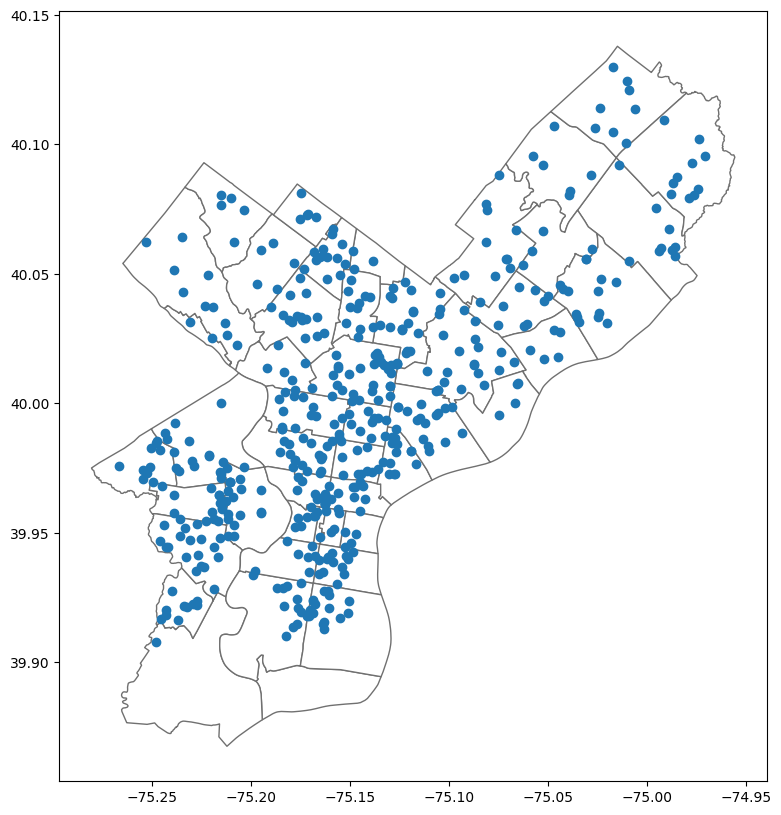

In [107]:
base = zip_gpd.plot(color='white', edgecolor='#707070', figsize=(10,10))
schools_gpd.plot(ax=base)
plt.show()

# Identifying the schools with the highest number of fatal crash counts in proximity in 2025: 

In [188]:
szone_gpd = schools_gpd.copy()
szone_gpd['geometry'] = schools_gpd['geometry'].to_crs(epsg=3857).buffer(800).to_crs(epsg=4326)

c2025 = crashes[crashes['year'] == 2025]
c2025_gpd = gpd.GeoDataFrame(c2025, geometry=gpd.points_from_xy(x=c2025['lng'], y=c2025['lat']))
c2025_gpd.crs = 'epsg:4326'

isect2025 = gpd.sjoin(szone_gpd, c2025_gpd)

ccnt2025 = pd.DataFrame(isect2025.groupby('school_name').size()).rename(columns={0:'crash_cnt2025'})

In [191]:
ccnt2025.sort_values('crash_cnt2025', ascending=False).head(5)

,crash_cnt2025
school_name,
"WILLARD, FRANCES E. SCHOOL",7
"CONWELL, RUSSELL MIDDLE SCHOOL",6
"MASTBAUM, JULES E. HIGH SCHOOL",5
"ELKIN, LEWIS SCHOOL",4
STUDENT TRANSITION CENTER,4


### The schools with the highest number of the fatal car accidents in 800 meter proximity were: 
- WilLard, Frances E. School with 7 accidents
- Conwell, Russell Middle School with 6 accidents
- Mastbraum, Jules E. High School with 5 accidents

# How many fatal vehicular crashes occured within a one mile radius of University City in Philadelphia in 2025?

In [65]:
upenn = gpd.GeoSeries([Point(-75.1932, 39.9522)], crs='epsg:4326')

In [116]:
upenn_zone = upenn.to_crs(epsg=3857).buffer(1609).to_crs(epsg=4326)


In [114]:
upenn_zone_gdf = gpd.GeoDataFrame(geometry=upenn_zone)
schools_near_upenn = gpd.sjoin(schools_gpd, upenn_zone_gdf)

In [113]:
schools_near_upenn

,X,Y,aun,school_num,location_id,school_name,school_name_label,street_address,zip_code,phone_number,grade_level,grade_org,enrollment,type,type_specific,objectid,geometry,index_right
52,-8.369198e+06,4.858227e+06,226515462.0,NaN,NaN,PHILADELPHIA SCHOOL,PHILADELPHIA SCHOOL,2501-29 LOMBARD ST,19146,(215) 545-5323,ELEMENTARY/MIDDLE,PREK-8,NaN,3,PRIVATE,53,POINT (-75.18178 39.94689),0
254,-8.370635e+06,4.859829e+06,126515001.0,3783.0,1390.0,"POWEL, SAMUEL SCHOOL",SAMUEL POWEL SCHOOL,3610 WARREN ST,19104,(215) 400-7740,ELEMENTARY SCHOOL,K-4,342.0,1,DISTRICT,255,POINT (-75.1947 39.95792),0
300,-8.371842e+06,4.859692e+06,126515001.0,7780.0,1050.0,"ROBESON, PAUL HIGH SCHOOL",PAUL ROBESON HIGH SCHOOL FOR HUMAN SERVICES,4125 LUDLOW ST,19104,(215) 400-7780,HIGH SCHOOL,9-12,300.0,1,DISTRICT,301,POINT (-75.20554 39.95697),0
398,-8.370629e+06,4.859803e+06,126515001.0,NaN,2050.0,SCIENCE LEADERSHIP ACADEMY MIDDLE SCHOOL,SCIENCE LEADERSHIP ACADEMY MIDDLE SCHOOL,3610 WARREN ST,19104,(215) 400-8320,MIDDLE SCHOOL,5-8,351.0,1,DISTRICT,399,POINT (-75.19464 39.95774),0


## The closest schools near University City:
- Philadelphia School 
- Samuel Powel School 
- Paul Robeson High School for Human Services 
- Science Leadership Academy Middle School

## Among these schools, which had fatal crashes: 

In [154]:
crash_upenn = ccnt2025.merge(schools_near_upenn[['school_name']],on='school_name')

In [195]:
crash_upenn

,school_name,crash_cnt2025
0,"POWEL, SAMUEL SCHOOL",2
1,SCIENCE LEADERSHIP ACADEMY MIDDLE SCHOOL,2


## 4 total of fatal crashes occured near University City in the year of 2025 
- Powel, Samuel School = 2
- Science Leadership Academy Middle School = 2

# Mapping out all the schools and fatal crashes: 

#### As seen in the map, all the schools are blue dots with the fatal crashes marked as the orange. The blue circle indicates the upenn zone which is University City, with the green dots indicating the fatal incidents that occured within the zone.

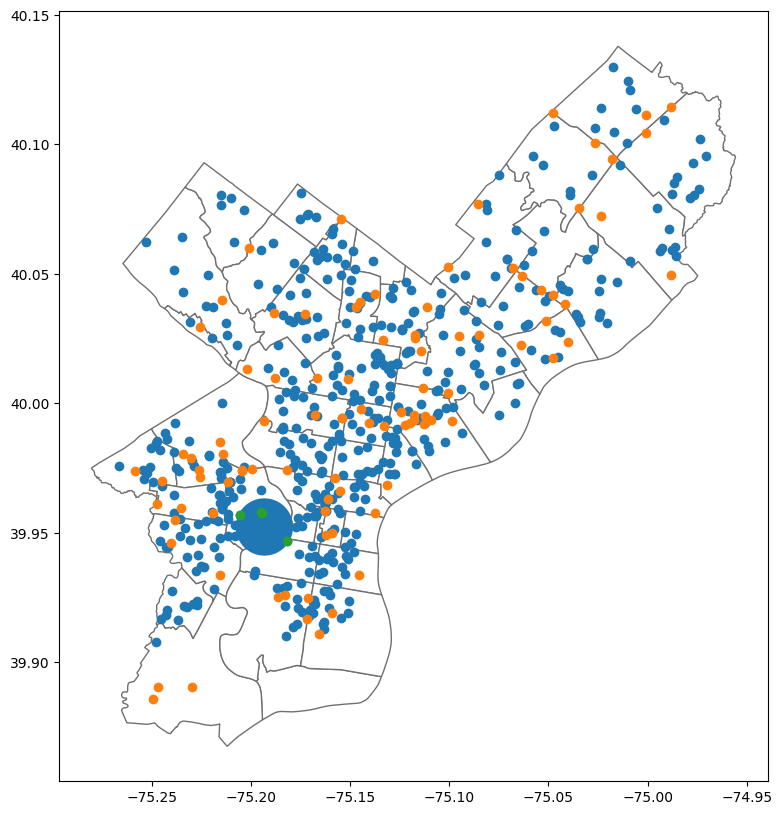

In [128]:
base = zip_gpd.plot(color='white', edgecolor='#707070', figsize=(10,10))

schools_gpd.plot(ax=base)
c2025_gpd.plot(ax=base)
upenn_zone.plot(ax=base)
schools_near_upenn.plot(ax=base)

plt.show()

## Let's look back to the highest number of fatal crash counts near schools in 2025: 

In [147]:
ccnt2025.sort_values('crash_cnt2025', ascending=False).head(60)

,crash_cnt2025
school_name,
"WILLARD, FRANCES E. SCHOOL",7
"CONWELL, RUSSELL MIDDLE SCHOOL",6
"MASTBAUM, JULES E. HIGH SCHOOL",5
"ELKIN, LEWIS SCHOOL",4
STUDENT TRANSITION CENTER,4
"HESTON, EDWARD SCHOOL",3
MASTERY CHARTER-SHOEMAKER,3
PARKWAY CENTER CITY MIDDLE COLLEGE HIGH SCHOOL,3
PEOPLE FOR PEOPLE,3


#### Within a 1 mile radius to University City, two schools reported a total of 4 fatal accidents, which is less than the top 5 schools with fatal accidents with one school reporting 7, the other 6, 5, 4, and so on. 

![](images/lightbulb.png){width=500}

# Compared to the other fatal accidents in all of Philadelphia...

### University city zone schools (Science Leadership Academy and Powel Samuel School)

The fatal crash count near Philadelphia schools in the city of Philadelphia is not evenly distributed. Only a small number of schools like WILLARD, FRANCES E. SCHOOL, CONWELL, RUSSELL MIDDLE SCHOOL, and MASTBAUM, JULES E. HIGH SCHOOL had a notably higher number of nearby fatal crashes than other Philadelphia schools. Many schools recorded one or two crashes, with schools within the University City buffer zone reporting two each and four total. There is no uniform pattern across Philadelphia, and it is difficult to say that University City schools are more dangerous or safer compared to other schools in the city of Philadelphia in terms of fatal accidents. It would be interesting to delve into this further and identify the buffer zone with the most reported fatal crashes and its association with street layout, roads, and infrastructures if there is data accumulated for that. 